**[과제 목표]**
PyTorch나 TensorFlow와 같은 프레임워크를 사용하지 않고, Python과 `NumPy` 행렬 연산만을 이용하여 객체지향적(Object-Oriented) 구조의 딥러닝 레이어를 직접 구현합니다. 이를 조합하여 2-Layer 인공신경망을 구축하고, 실제 차량 센서 데이터(가속도, 자이로스코프)를 4가지 주행 상태(급가속, 우회전, 좌회전, 급제동)로 분류합니다.

**[구현 지침]**
- `[TODO]`로 표시된 영역의 코드를 수학적 지식에 기반하여 직접 채워 넣으세요.
- 구현 시 `for`문 사용을 최소화하고, 가급적 NumPy의 행렬 연산(`np.dot`, `@`, 브로드캐스팅)을 활용하세요.

In [1]:
!curl -L -o driving-behavior-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/shashwatwork/driving-behavior-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6790k  100 6790k    0     0  3241k      0  0:00:02  0:00:02 --:--:-- 5789k


In [3]:
import zipfile
# zip 파일 열기 및 압축 해제
with zipfile.ZipFile('driving-behavior-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('driving-behavior-dataset')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 동일한 동작을 위한 랜덤 시드 고정
np.random.seed(42)

# ---------------------------------------------------------
# 1. 실제 차량 동역학 센서 데이터 (sensor_raw.csv) 로드
# ---------------------------------------------------------
def load_sensor_raw_data(csv_path='sensor_raw.csv', test_ratio=0.2):
    """
    가속도(AccX, AccY, AccZ) 및 자이로스코프(GyroX, GyroY, GyroZ) Raw 데이터를 로드합니다.
    클래스: 1(급가속), 2(우회전), 3(좌회전), 4(급제동)
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"'{csv_path}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")

    # 결측치 제거
    df = df.dropna()

    # 컬럼명이 'Class', 'Label', 'Target' 등으로 다를 수 있으므로 마지막 컬럼을 라벨로 지정합니다.
    feature_cols = df.columns[1:]
    label_col = df.columns[0]

    X = df[feature_cols].values

    # 모델 학습을 위해 라벨(1, 2, 3, 4)을 (0, 1, 2, 3) 형태의 인덱스로 변환합니다.
    Y = df[label_col].values.astype(int) - 1

    # 데이터셋 셔플링 (랜덤 시드 고정)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X = X[indices]
    Y = Y[indices]

    # Train / Test 분할
    split_idx = int(len(X) * (1 - test_ratio))
    X_train, X_test = X[:split_idx], X[split_idx:]
    Y_train, Y_test = Y[:split_idx], Y[split_idx:]

    # 데이터 정규화 (Standardization)
    # 훈련 데이터의 평균과 표준편차를 구한 뒤, 테스트 데이터에도 동일하게 적용합니다.
    mean_X = X_train.mean(axis=0)
    std_X = X_train.std(axis=0)
    std_X[std_X == 0] = 1e-8 # 0으로 나누어지는 오류 방지

    X_train = (X_train - mean_X) / std_X
    X_test = (X_test - mean_X) / std_X

    return X_train, Y_train, X_test, Y_test

# 데이터 로드 실행 (CSV 파일이 같은 폴더에 있다고 가정)
X_train, Y_train, X_test, Y_test = load_sensor_raw_data('driving-behavior-dataset/sensor_raw.csv')

# --- [중요] 클래스 개수가 4개로 변경되었으므로 파라미터 업데이트 ---
output_size = 4
Y_train_one_hot = np.eye(output_size)[Y_train]

print(f"Train Features Shape: {X_train.shape}")
print(f"Train Labels Shape (One-hot): {Y_train_one_hot.shape}")
print(f"Test Features Shape: {X_test.shape}")

# 실제 데이터의 클래스 분포 확인
unique, counts = np.unique(Y_train, return_counts=True)
class_names = ['Accel (0)', 'Right (1)', 'Left (2)', 'Brake (3)']
distribution = {class_names[k]: v for k, v in zip(unique, counts)}
print(f"\nClass Distribution (Train): {distribution}")

Train Features Shape: (891, 6)
Train Labels Shape (One-hot): (891, 4)
Test Features Shape: (223, 6)

Class Distribution (Train): {'Accel (0)': np.int64(209), 'Right (1)': np.int64(237), 'Left (2)': np.int64(269), 'Brake (3)': np.int64(176)}


### 1. 딥러닝 레이어(Layer) 모듈화 구현
딥러닝 모델을 구성하는 핵심 계층들을 각각의 클래스(Class)로 구현합니다. 각 클래스는 입력 데이터를 받아 출력 데이터를 반환하는 `forward` 함수와, 상위 계층에서 전달받은 기울기(Gradient)를 이용하여 파라미터를 업데이트하고 하위 계층으로 기울기를 전달하는 `backward` 함수를 가져야 합니다.

In [5]:
class Linear:
    """완전 연결 계층 (Fully Connected Layer)"""
    def __init__(self, input_dim, output_dim):
        # 가중치(W)와 편향(b) 초기화
        self.W = np.random.randn(input_dim, output_dim) * 0.01
        self.b = np.zeros((1, output_dim))
        self.x = None

    def forward(self, x):
        self.x = x
        # ==========================================
        # [TODO 1] Linear Forward 구현
        # Z = XW + b 행렬 연산을 수행하여 반환하세요.
        # ==========================================
        out = x @ self.W + self.b
        return out

    def backward(self, dout, lr):
        # ==========================================
        # [TODO 2] Linear Backward 및 가중치 업데이트
        # dout: 상위 계층에서 넘어온 기울기 (dZ)
        # 1. dW, db, dx (이전 계층으로 전달할 기울기)를 계산하세요.
        # 2. 계산된 기울기와 학습률(lr)을 이용하여 self.W, self.b를 업데이트하세요.
        # ==========================================
        dW = self.x.T @ dout
        db = np.sum(dout, axis=0, keepdims=True)
        dx = dout @ self.W.T
        self.W = self.W - lr * dW
        self.b = self.b - lr * db
        return dx


class ReLU:
    """활성화 함수 (ReLU)"""
    def __init__(self):
        self.mask = None

    def forward(self, x):
        # ==========================================
        # [TODO 3] ReLU Forward 구현
        # x가 0 이하인 인덱스를 self.mask에 저장하고, 해당 위치의 값을 0으로 만든 뒤 반환하세요.
        # ==========================================
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0
        return out

    def backward(self, dout):
        # ==========================================
        # [TODO 4] ReLU Backward 구현
        # self.mask를 이용하여 순전파 때 0 이하였던 곳의 기울기를 0으로 차단하여 반환하세요.
        # ==========================================
        dout[self.mask] = 0
        dx = dout
        return dx


class SoftmaxWithLoss:
    """다중 분류를 위한 Softmax 활성화 함수 및 Cross-Entropy Loss 결합 계층"""
    def __init__(self):
        self.y = None # Softmax 출력값
        self.t = None # 정답 라벨 (One-hot vector)

    def forward(self, x, t):
        self.t = t
        # ==========================================
        # [TODO 5] Softmax 및 Cross Entropy Loss 계산
        # 1. 입력 x에 Softmax를 적용하여 self.y를 구하세요. (오버플로우 방지를 위해 입력의 최댓값을 빼주는 트릭 사용)
        # 2. self.y와 self.t를 이용하여 Cross Entropy Loss를 계산하고 반환하세요.
        # (log 0 방지를 위해 아주 작은 값 1e-7을 더해주세요)
        # ==========================================
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        self.y = exp_x / np.sum(exp_x, axis=1, keepdims=True)

        m = self.t.shape[0]
        loss = -np.sum(self.t * np.log(self.y + 1e-7)) / m
        return loss

    def backward(self, dout=1):
        # ==========================================
        # [TODO 6] Softmax + CrossEntropy 역전파 수식 구현
        # (예측 확률 - 정답) / 배치 크기 형태의 수식을 구현하여 반환하세요.
        # ==========================================
        m = self.t.shape[0]
        dx = (self.y - self.t) / m
        return dx

### 2. 모델 조립 및 학습 (Model Assembly & Training)
위에서 직접 구현한 모듈들을 레고 블록처럼 조립하여 `TwoLayerNet` 모델을 완성합니다.

In [6]:
class TwoLayerNet:
    """모듈화된 레이어를 조립하여 만든 2-Layer 인공신경망"""
    def __init__(self, input_size, hidden_size, output_size):
        # 레이어 인스턴스 생성 및 배치
        self.layer1 = Linear(input_size, hidden_size)
        self.relu = ReLU()
        self.layer2 = Linear(hidden_size, output_size)
        self.loss_layer = SoftmaxWithLoss()

    def forward(self, x):
        # ==========================================
        # [TODO 7] 네트워크 순전파 파이프라인
        # layer1 -> relu -> layer2 순으로 데이터를 통과시켜 최종 출력(Logits)을 반환하세요.
        # ==========================================
        out = self.layer1.forward(x)
        out = self.relu.forward(out)
        out = self.layer2.forward(out)
        return out

    def calculate_loss(self, x, t):
        # 최종 레이어의 출력값을 구한 뒤, Loss Layer를 통과시켜 오차를 계산합니다.
        logits = self.forward(x)
        loss = self.loss_layer.forward(logits, t)
        return loss

    def backward(self, lr):
        # ==========================================
        # [TODO 8] 네트워크 역전파 파이프라인
        # loss_layer -> layer2 -> relu -> layer1 순으로 역전파(backward)를 호출하여 기울기를 갱신하세요.
        # ==========================================
        dout = self.loss_layer.backward()
        dout = self.layer2.backward(dout, lr)
        dout = self.relu.backward(dout)
        dout = self.layer1.backward(dout, lr)
        pass

**[학습 루프 구성]**

In [19]:

# --- 네트워크 초기화 및 학습 루프 ---
input_size = X_train.shape[1]
hidden_size = 16
output_size = 4
learning_rate = 0.5

model = TwoLayerNet(input_size, hidden_size, output_size)
epochs = 500
losses = []

for epoch in range(epochs):
    # ==========================================
    # [TODO 9] 학습 1스텝 구현
    # 1. 모델의 calculate_loss를 호출하여 손실(Loss)을 구하고 losses 리스트에 저장합니다.
    # 2. 모델의 backward를 호출하여 파라미터를 업데이트합니다.
    # ==========================================
    loss = model.calculate_loss(X_train, Y_train_one_hot)
    losses.append(loss)
    model.backward(learning_rate)
    pass

    # TODO 9를 올바르게 구현한 후 아래 주석을 해제하세요.
    if (epoch+1) % 50 == 0:
         print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')

Epoch [50/500], Loss: 1.2191
Epoch [100/500], Loss: 1.0995
Epoch [150/500], Loss: 0.9225
Epoch [200/500], Loss: 0.8635
Epoch [250/500], Loss: 0.8332
Epoch [300/500], Loss: 0.8084
Epoch [350/500], Loss: 0.7898
Epoch [400/500], Loss: 0.7756
Epoch [450/500], Loss: 0.7641
Epoch [500/500], Loss: 0.7545


### 3. 평가 및 시각화 (Evaluation & Visualization)
학습이 끝난 모델을 바탕으로 테스트 데이터(Test)에 대한 추론을 진행하고, 모델이 데이터를 올바르게 군집화했는지 시각적으로 확인합니다.

Overall Accuracy: 65.92%

PCA Explained Variance Ratio: PC1(0.44), PC2(0.18)


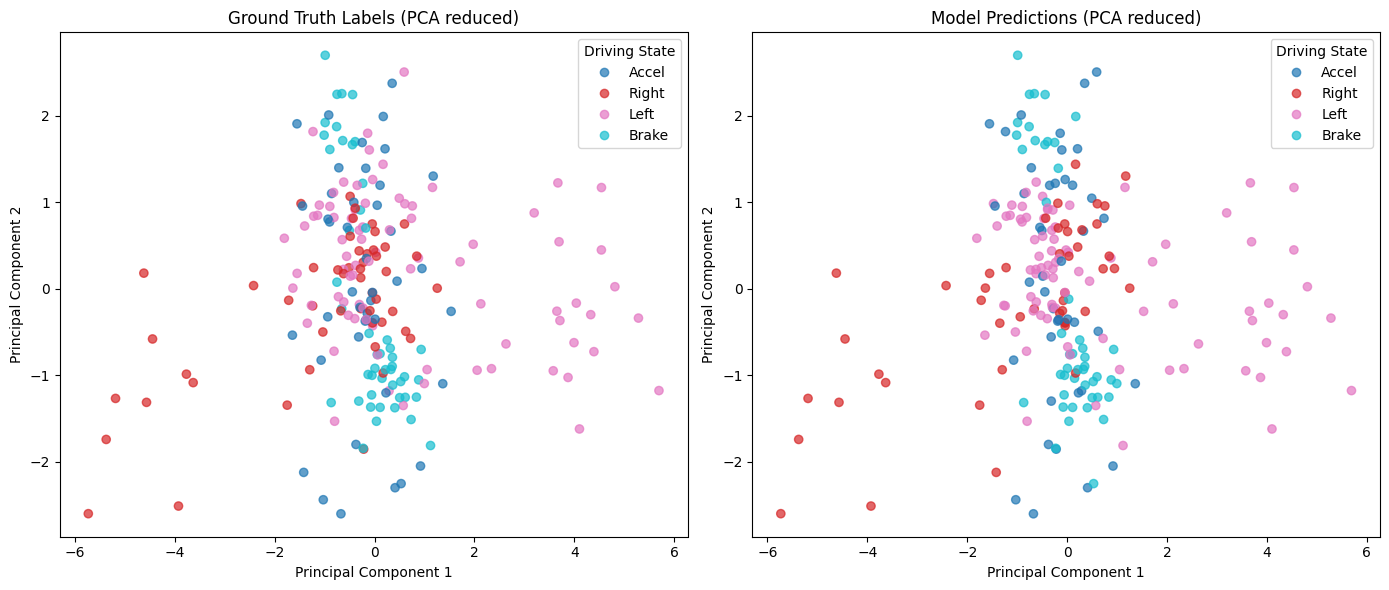

In [20]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 모델 추론 (Test 데이터 대상)
# ---------------------------------------------------------
# 학습된 모델을 사용하여 전체 데이터셋 Forward Pass
logits = model.forward(X_test)
predictions = np.argmax(logits, axis=1)

# 정확도 계산
accuracy = np.mean(predictions == Y_test)
print(f'Overall Accuracy: {accuracy * 100:.2f}%\n')

# ---------------------------------------------------------
# 2. 결과 시각화 (PCA를 활용한 2차원 축소)
# ---------------------------------------------------------
# 6차원의 특징(Feature) 공간을 2차원으로 축소하여 데이터의 분포를 시각화합니다.
pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(X_test)

# PCA의 설명 분산 비율 출력
explained_variance = pca.explained_variance_ratio_
print(f"PCA Explained Variance Ratio: PC1({explained_variance[0]:.2f}), PC2({explained_variance[1]:.2f})")

# t-SNE 적용 시 아래 주석 해제
# tsne = TSNE(n_components=2, random_state=42)
# X_all_2d = tsne.fit_transform(X_all)

plt.figure(figsize=(14, 6))
class_labels = ['Accel', 'Right', 'Left', 'Brake']

# 왼쪽: Ground Truth Labels
plt.subplot(1, 2, 1)
# 이산형 데이터에 적합한 tab10 컬러맵 사용
scatter1 = plt.scatter(X_all_2d[:, 0], X_all_2d[:, 1],
                       c=Y_test, cmap='tab10', alpha=0.7, edgecolors=None)
plt.title('Ground Truth Labels (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
# Colorbar 대신 Legend 적용
plt.legend(handles=scatter1.legend_elements()[0], labels=class_labels, title="Driving State")

# 오른쪽: Model Predictions
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_all_2d[:, 0], X_all_2d[:, 1],
                       c=predictions, cmap='tab10', alpha=0.7, edgecolors=None)
plt.title('Model Predictions (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
# Colorbar 대신 Legend 적용
plt.legend(handles=scatter2.legend_elements()[0], labels=class_labels, title="Driving State")

plt.tight_layout()
plt.show()